In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

print("Batch Normalization Matematiği")
print("=" * 40)
print()
print("Bugün cevaplayacağımız sorular:")
print("1. İç kovaryat kayması (ICS) nedir?")
print("2. Batch Norm tam olarak ne hesaplıyor?")
print("3. γ ve β parametreleri neden var?")
print("4. Eğitim vs test zamanı farkı nedir?")
print("5. Neden bu kadar etkili — sezgi ve matematik")
print()
print("Anahtar: BN olmadan derin ağlar eğitmek çok zor!")

np.random.seed(42)
torch.manual_seed(42)

Batch Normalization Matematiği

Bugün cevaplayacağımız sorular:
1. İç kovaryat kayması (ICS) nedir?
2. Batch Norm tam olarak ne hesaplıyor?
3. γ ve β parametreleri neden var?
4. Eğitim vs test zamanı farkı nedir?
5. Neden bu kadar etkili — sezgi ve matematik

Anahtar: BN olmadan derin ağlar eğitmek çok zor!


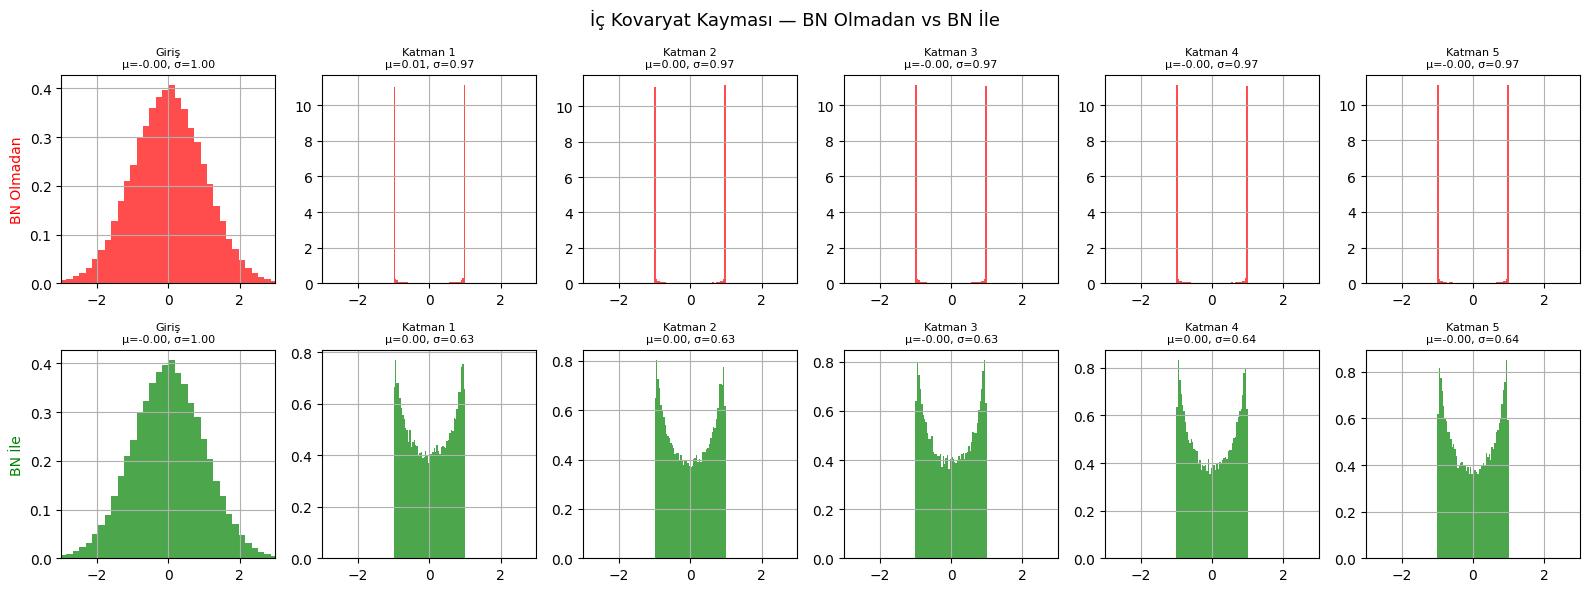

BN olmadan: Son katmanda dağılım tamamen değişti!
BN ile:     Her katmanda dağılım stabil kalıyor!


In [2]:
# İÇ KOVARYAT KAYMASI (Internal Covariate Shift)
#
# Problem: Her katmanın girişi bir önceki katmanın çıkışı
# Ağırlıklar güncellenince her katmanın giriş dağılımı değişiyor
# Model her adımda "yeni bir veriyle" karşılaşıyor gibi davranıyor
# Bu eğitimi yavaşlatıyor ve dengesizleştiriyor

# Simüle et — 3 katmanlı ağda aktivasyon dağılımları
def forward_without_bn(x, weights):
    activations = [x]
    for w in weights:
        x = np.tanh(x @ w)
        activations.append(x)
    return activations

def forward_with_bn(x, weights):
    activations = [x]
    for w in weights:
        z = x @ w
        # Batch Norm uygula
        mu = z.mean(axis=0)
        sigma = z.std(axis=0) + 1e-8
        z_norm = (z - mu) / sigma
        x = np.tanh(z_norm)
        activations.append(x)
    return activations

# Veri ve ağırlıklar
n_samples = 1000
n_layers = 5
dim = 50

X = np.random.randn(n_samples, dim)
# Kasıtlı büyük ağırlıklar — dağılım kaymasını görmek için
weights = [np.random.randn(dim, dim) * 2 for _ in range(n_layers)]

acts_no_bn = forward_without_bn(X, weights)
acts_with_bn = forward_with_bn(X, weights)

fig, axes = plt.subplots(2, n_layers+1, figsize=(16, 6))

for i, (act_no, act_bn) in enumerate(zip(acts_no_bn, acts_with_bn)):
    # BN olmadan
    axes[0, i].hist(act_no.flatten(), bins=50, color='red',
                   alpha=0.7, density=True)
    axes[0, i].set_title(f"{'Giriş' if i==0 else f'Katman {i}'}\n"
                        f"μ={act_no.mean():.2f}, σ={act_no.std():.2f}",
                        fontsize=8)
    axes[0, i].set_xlim(-3, 3)
    axes[0, i].grid(True)

    # BN ile
    axes[1, i].hist(act_bn.flatten(), bins=50, color='green',
                   alpha=0.7, density=True)
    axes[1, i].set_title(f"{'Giriş' if i==0 else f'Katman {i}'}\n"
                        f"μ={act_bn.mean():.2f}, σ={act_bn.std():.2f}",
                        fontsize=8)
    axes[1, i].set_xlim(-3, 3)
    axes[1, i].grid(True)

axes[0, 0].set_ylabel("BN Olmadan", fontsize=10, color='red')
axes[1, 0].set_ylabel("BN İle", fontsize=10, color='green')

plt.suptitle("İç Kovaryat Kayması — BN Olmadan vs BN İle", fontsize=13)
plt.tight_layout()
plt.show()

print("BN olmadan: Son katmanda dağılım tamamen değişti!")
print("BN ile:     Her katmanda dağılım stabil kalıyor!")

=== Batch Normalization Adım Adım ===

Girdi istatistikleri:
  μ = [4.67 4.79 4.79 4.96]
  σ = [1.97 3.01 3.16 3.01]

Batch ortalaması (μ_B): [4.6712 4.7859 4.7933 4.9624]
Batch varyansı (σ²_B):  [3.8661 9.0697 9.9779 9.0833]

Normalize sonrası:
  μ ≈ [-0.  0.  0. -0.] (sıfıra yakın)
  σ ≈ [1. 1. 1. 1.] (bire yakın)

γ=[1. 1. 1. 1.], β=[0. 0. 0. 0.]
Çıktı istatistikleri:
  μ = [-0.  0.  0. -0.]
  σ = [1. 1. 1. 1.]


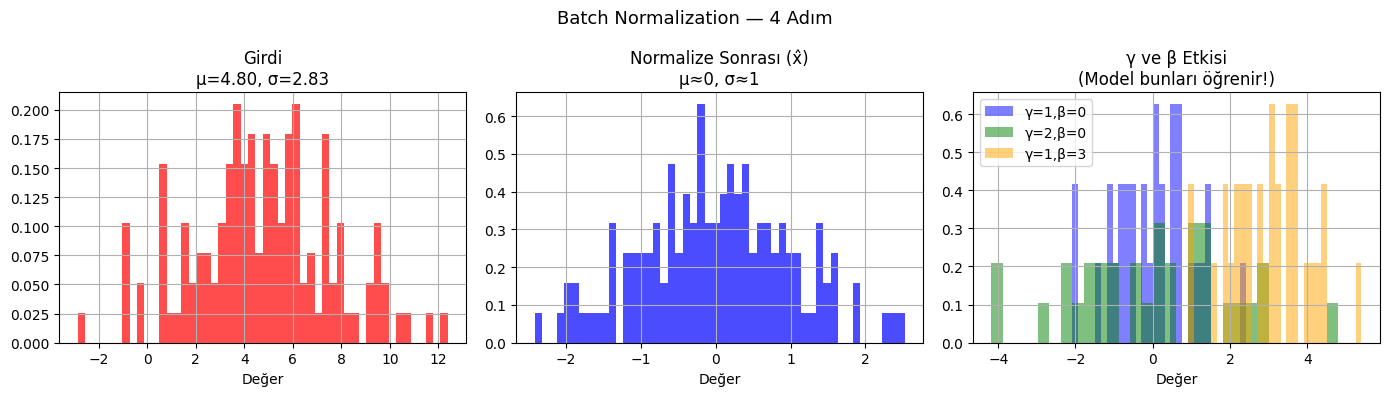

In [3]:
# BATCH NORMALIZATION — TAM MATEMATİK
#
# 4 adım:
# 1. Batch ortalaması:  μ_B = (1/m) * Σxᵢ
# 2. Batch varyansı:    σ²_B = (1/m) * Σ(xᵢ - μ_B)²
# 3. Normalize et:      x̂ᵢ = (xᵢ - μ_B) / √(σ²_B + ε)
# 4. Ölçekle ve kaydır: yᵢ = γ*x̂ᵢ + β
#
# γ (gamma) ve β (beta) öğrenilen parametreler!

def batch_norm_elle(x, gamma, beta, eps=1e-8):
    # Adım 1: Ortalama
    mu = x.mean(axis=0)

    # Adım 2: Varyans
    var = x.var(axis=0)

    # Adım 3: Normalize
    x_hat = (x - mu) / np.sqrt(var + eps)

    # Adım 4: Ölçekle ve kaydır
    out = gamma * x_hat + beta

    return out, mu, var, x_hat

# Test
np.random.seed(42)
batch_size = 32
features = 4

x = np.random.randn(batch_size, features) * 3 + 5  # Ortalama 5, std 3
gamma = np.ones(features)   # Başlangıçta 1
beta = np.zeros(features)   # Başlangıçta 0

out, mu, var, x_hat = batch_norm_elle(x, gamma, beta)

print("=== Batch Normalization Adım Adım ===")
print(f"\nGirdi istatistikleri:")
print(f"  μ = {x.mean(axis=0).round(2)}")
print(f"  σ = {x.std(axis=0).round(2)}")

print(f"\nBatch ortalaması (μ_B): {mu.round(4)}")
print(f"Batch varyansı (σ²_B):  {var.round(4)}")

print(f"\nNormalize sonrası:")
print(f"  μ ≈ {x_hat.mean(axis=0).round(6)} (sıfıra yakın)")
print(f"  σ ≈ {x_hat.std(axis=0).round(6)} (bire yakın)")

print(f"\nγ={gamma}, β={beta}")
print(f"Çıktı istatistikleri:")
print(f"  μ = {out.mean(axis=0).round(4)}")
print(f"  σ = {out.std(axis=0).round(4)}")

# Görselleştir
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(x.flatten(), bins=50, color='red', alpha=0.7, density=True)
axes[0].set_title(f"Girdi\nμ={x.mean():.2f}, σ={x.std():.2f}")
axes[0].set_xlabel("Değer")
axes[0].grid(True)

axes[1].hist(x_hat.flatten(), bins=50, color='blue', alpha=0.7, density=True)
axes[1].set_title(f"Normalize Sonrası (x̂)\nμ≈0, σ≈1")
axes[1].set_xlabel("Değer")
axes[1].grid(True)

# Farklı γ ve β değerleri
for g, b, renk, etiket in [(1, 0, 'blue', 'γ=1,β=0'),
                            (2, 0, 'green', 'γ=2,β=0'),
                            (1, 3, 'orange', 'γ=1,β=3')]:
    out_custom, _, _, _ = batch_norm_elle(x, g*np.ones(features),
                                          b*np.ones(features))
    axes[2].hist(out_custom[:, 0], bins=30, alpha=0.5,
                color=renk, label=etiket, density=True)

axes[2].set_title("γ ve β Etkisi\n(Model bunları öğrenir!)")
axes[2].set_xlabel("Değer")
axes[2].legend()
axes[2].grid(True)

plt.suptitle("Batch Normalization — 4 Adım", fontsize=13)
plt.tight_layout()
plt.show()

=== EĞİTİM vs TEST MODU ===

Eğitim modu:
  Çıktı μ: [ 0.  0. -0. -0.]
  Çıktı σ: [1.016 1.016 1.016 1.016]
  Running mean: [0.468  0.6024 0.4771 0.55  ]

Test modu (tek örnek):
  Girdi: [[3.033 7.573 0.119 0.815]]
  Çıktı: [[ 1.839  5.55  -0.276  0.204]]
  Running mean kullanıldı: [0.468  0.6024 0.4771 0.55  ]


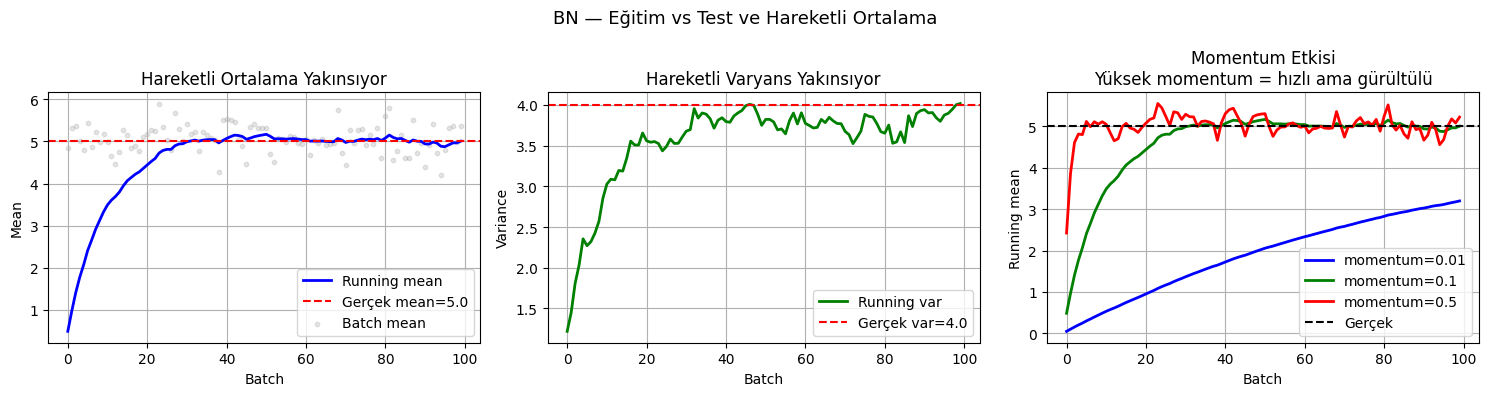

In [4]:
# EĞİTİM vs TEST ZAMANI
#
# Eğitim: Her batch'in kendi μ ve σ'sı kullanılır
# Test:   Eğitim boyunca biriken hareketli ortalama kullanılır
#         (Tek örnek için batch istatistiği hesaplanamaz!)
#
# running_mean = momentum * running_mean + (1-momentum) * batch_mean
# running_var  = momentum * running_var  + (1-momentum) * batch_var

# Hareketli ortalama simülasyonu
n_batches = 100
momentum = 0.1
true_mean = 5.0
true_std = 2.0

running_mean = 0.0
running_var = 1.0
running_means = []
running_vars = []
batch_means = []

for i in range(n_batches):
    # Batch örnekle
    batch = np.random.randn(32) * true_std + true_mean
    batch_mean = batch.mean()
    batch_var = batch.var()
    batch_means.append(batch_mean)

    # Hareketli ortalama güncelle
    running_mean = (1-momentum) * running_mean + momentum * batch_mean
    running_var = (1-momentum) * running_var + momentum * batch_var
    running_means.append(running_mean)
    running_vars.append(running_var)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Running mean
axes[0].plot(running_means, 'b-', linewidth=2, label='Running mean')
axes[0].axhline(y=true_mean, color='red', linestyle='--',
               label=f'Gerçek mean={true_mean}')
axes[0].scatter(range(n_batches), batch_means, alpha=0.2,
               color='gray', s=10, label='Batch mean')
axes[0].set_title("Hareketli Ortalama Yakınsıyor")
axes[0].set_xlabel("Batch")
axes[0].set_ylabel("Mean")
axes[0].legend()
axes[0].grid(True)

# Running var
axes[1].plot(running_vars, 'g-', linewidth=2, label='Running var')
axes[1].axhline(y=true_std**2, color='red', linestyle='--',
               label=f'Gerçek var={true_std**2}')
axes[1].set_title("Hareketli Varyans Yakınsıyor")
axes[1].set_xlabel("Batch")
axes[1].set_ylabel("Variance")
axes[1].legend()
axes[1].grid(True)

# Eğitim vs Test modu
print("=== EĞİTİM vs TEST MODU ===\n")

bn = nn.BatchNorm1d(4)
x_torch = torch.randn(32, 4) * 3 + 5

# Eğitim modu
bn.train()
out_train = bn(x_torch)
print(f"Eğitim modu:")
print(f"  Çıktı μ: {out_train.mean(dim=0).detach().numpy().round(4)}")
print(f"  Çıktı σ: {out_train.std(dim=0).detach().numpy().round(4)}")
print(f"  Running mean: {bn.running_mean.numpy().round(4)}")

# Test modu
bn.eval()
x_test = torch.randn(1, 4) * 3 + 5  # Tek örnek!
out_eval = bn(x_test)
print(f"\nTest modu (tek örnek):")
print(f"  Girdi: {x_test.numpy().round(3)}")
print(f"  Çıktı: {out_eval.detach().numpy().round(3)}")
print(f"  Running mean kullanıldı: {bn.running_mean.numpy().round(4)}")

# Momentum görselleştirme
momentumlar = [0.01, 0.1, 0.5]
renkler_m = ['blue', 'green', 'red']

for mom, renk in zip(momentumlar, renkler_m):
    rm = 0.0
    rms = []
    for bm in batch_means:
        rm = (1-mom) * rm + mom * bm
        rms.append(rm)
    axes[2].plot(rms, color=renk, linewidth=2, label=f'momentum={mom}')

axes[2].axhline(y=true_mean, color='black', linestyle='--', label='Gerçek')
axes[2].set_title("Momentum Etkisi\nYüksek momentum = hızlı ama gürültülü")
axes[2].set_xlabel("Batch")
axes[2].set_ylabel("Running mean")
axes[2].legend()
axes[2].grid(True)

plt.suptitle("BN — Eğitim vs Test ve Hareketli Ortalama", fontsize=13)
plt.tight_layout()
plt.show()

In [5]:
# BN OLMADAN vs BN İLE — GERÇEK EĞİTİM KARŞILAŞTIRMASI

import torch
import torch.nn as nn
import torchvision
import torchvision.transforms as transforms

# MNIST veri
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
train_dataset = torchvision.datasets.MNIST(
    root='./data', train=True, download=True, transform=transform)
train_loader = torch.utils.data.DataLoader(
    train_dataset, batch_size=128, shuffle=True)

# Model — BN olmadan
class MLPNoBN(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, 256), nn.ReLU(),
            nn.Linear(256, 10)
        )
    def forward(self, x): return self.layers(x)

# Model — BN ile
class MLPWithBN(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256, 256), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256, 256), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256, 256), nn.BatchNorm1d(256), nn.ReLU(),
            nn.Linear(256, 10)
        )
    def forward(self, x): return self.layers(x)

def train_model(model, n_epochs=5, lr=0.01):
    optimizer = torch.optim.SGD(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()
    losses = []

    for epoch in range(n_epochs):
        model.train()
        epoch_loss, correct = 0, 0
        for X, y in train_loader:
            optimizer.zero_grad()
            out = model(X)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            correct += (out.argmax(1) == y).sum().item()

        avg_loss = epoch_loss / len(train_loader)
        acc = correct / len(train_dataset)
        losses.append((avg_loss, acc))
        print(f"  Epoch {epoch+1} | Loss: {avg_loss:.4f} | Acc: {acc:.2%}")
    return losses

print("BN OLMADAN eğitim (lr=0.01):")
model_no_bn = MLPNoBN()
losses_no_bn = train_model(model_no_bn)

print("\nBN İLE eğitim (lr=0.01):")
model_with_bn = MLPWithBN()
losses_with_bn = train_model(model_with_bn)

BN OLMADAN eğitim (lr=0.01):
  Epoch 1 | Loss: 2.2811 | Acc: 17.84%
  Epoch 2 | Loss: 1.7871 | Acc: 41.02%
  Epoch 3 | Loss: 0.7612 | Acc: 76.20%
  Epoch 4 | Loss: 0.5001 | Acc: 85.13%
  Epoch 5 | Loss: 0.3993 | Acc: 88.15%

BN İLE eğitim (lr=0.01):
  Epoch 1 | Loss: 0.5051 | Acc: 88.20%
  Epoch 2 | Loss: 0.1702 | Acc: 95.46%
  Epoch 3 | Loss: 0.1174 | Acc: 96.84%
  Epoch 4 | Loss: 0.0873 | Acc: 97.72%
  Epoch 5 | Loss: 0.0681 | Acc: 98.24%


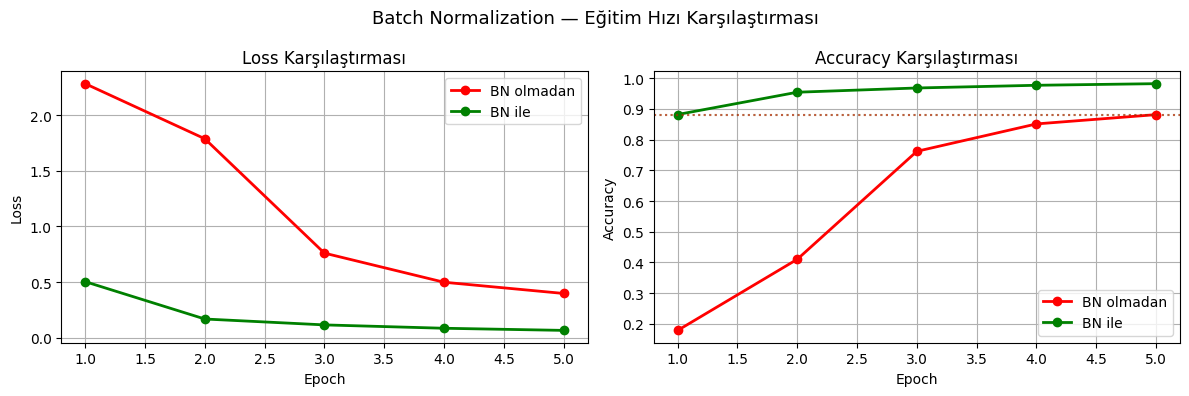


=== ÖZET ===
BN olmadan 5 epoch sonunda: 88.15%
BN ile     1 epoch sonunda: 88.20%

BN ile     5 epoch sonunda: 98.24%
Fark: 10.09% daha iyi!


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

epochs = range(1, 6)
losses_nb = [l[0] for l in losses_no_bn]
losses_wb = [l[0] for l in losses_with_bn]
accs_nb = [l[1] for l in losses_no_bn]
accs_wb = [l[1] for l in losses_with_bn]

axes[0].plot(epochs, losses_nb, 'r-o', linewidth=2, label='BN olmadan')
axes[0].plot(epochs, losses_wb, 'g-o', linewidth=2, label='BN ile')
axes[0].set_title("Loss Karşılaştırması")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(epochs, accs_nb, 'r-o', linewidth=2, label='BN olmadan')
axes[1].plot(epochs, accs_wb, 'g-o', linewidth=2, label='BN ile')
axes[1].set_title("Accuracy Karşılaştırması")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].legend()
axes[1].grid(True)

# BN ile epoch 1 = BN olmadan epoch 5 çizgisi
axes[1].axhline(y=accs_wb[0], color='green', linestyle=':',
               alpha=0.5, label=f'BN Epoch1={accs_wb[0]:.2%}')
axes[1].axhline(y=accs_nb[-1], color='red', linestyle=':',
               alpha=0.5, label=f'NoBN Epoch5={accs_nb[-1]:.2%}')

plt.suptitle("Batch Normalization — Eğitim Hızı Karşılaştırması", fontsize=13)
plt.tight_layout()
plt.show()

print("\n=== ÖZET ===")
print(f"BN olmadan 5 epoch sonunda: {accs_nb[-1]:.2%}")
print(f"BN ile     1 epoch sonunda: {accs_wb[0]:.2%}")
print(f"\nBN ile     5 epoch sonunda: {accs_wb[-1]:.2%}")
print(f"Fark: {accs_wb[-1]-accs_nb[-1]:.2%} daha iyi!")